In [ ]:
from astropy.io import fits
import numpy as np

In [ ]:
!pip install photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:00


In [ ]:
filename = "ngc3982_i.fits"

hdul = fits.open(filename)

hdul.info()

print("\nShape:", hdul[0].data.shape)
print("\nHeader keywords:")
print("NAXIS =", hdul[0].header.get("NAXIS"))
print("NAXIS1 =", hdul[0].header.get("NAXIS1"))
print("NAXIS2 =", hdul[0].header.get("NAXIS2"))

hdul.close()

Filename: ngc3982_i.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     527   (400, 400)   float32   

Shape: (400, 400)

Header keywords:
NAXIS = 2
NAXIS1 = 400
NAXIS2 = 400


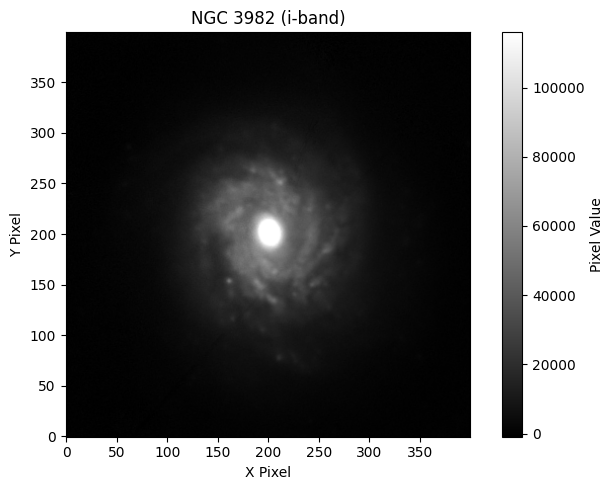

In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import PercentileInterval

data = fits.getdata("ngc3982_i.fits")

interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data)

plt.figure(figsize=(7,5))
plt.imshow(data, origin='lower', cmap='gray',
           vmin=vmin, vmax=vmax)
plt.colorbar(label='Pixel Value')
plt.title("NGC 3982 (i-band)")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from photutils.centroids import centroid_com

data = fits.getdata("ngc3982_i.fits")

edge_pixels = np.concatenate([
    data[:20, :].ravel(),
    data[-20:, :].ravel(),
    data[:, :20].ravel(),
    data[:, -20:].ravel()
])

background = np.median(edge_pixels)

data_sub = data - background

data_sub[data_sub < 0] = 0

xcen, ycen = centroid_com(data_sub)

print(f"Galaxy center:")
print(f"x = {xcen:.2f}")
print(f"y = {ycen:.2f}")

Galaxy center:
x = 201.74
y = 198.62


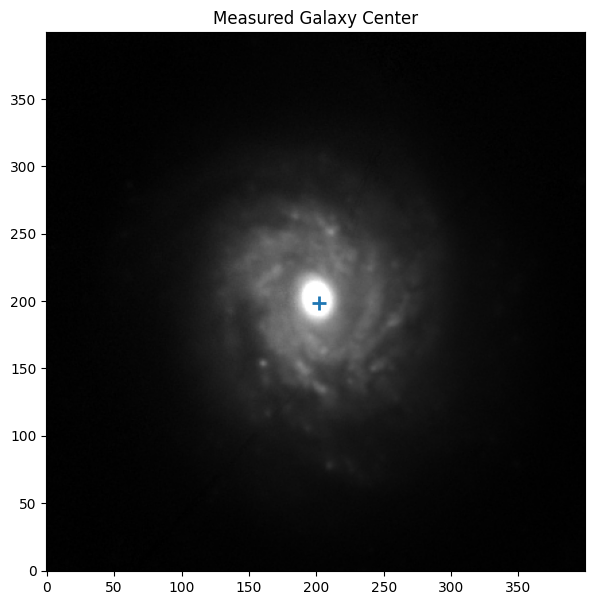

In [ ]:
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data)

plt.figure(figsize=(7,7))
plt.imshow(data, origin='lower', cmap='gray',
           vmin=vmin, vmax=vmax)

plt.scatter(xcen, ycen,
            s=100,
            marker='+',
            linewidths=2)

plt.title("Measured Galaxy Center")
plt.show()

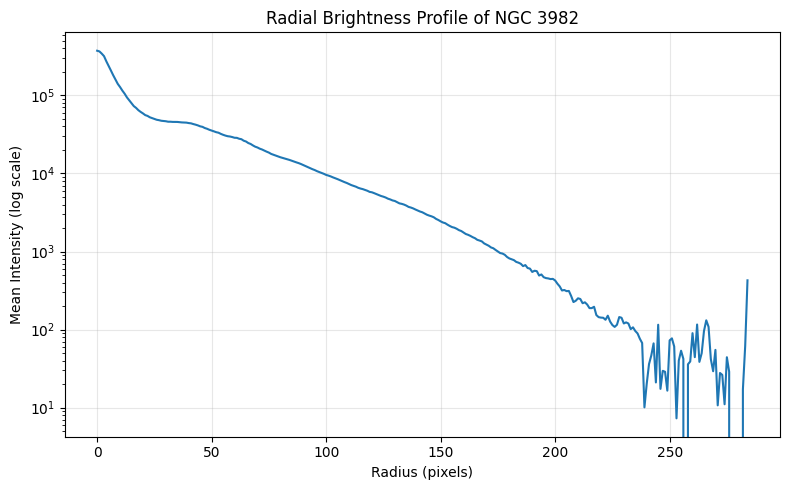

In [ ]:
xcen = 201.74
ycen = 198.62

y, x = np.indices(data.shape)

r = np.sqrt((x - xcen)**2 + (y - ycen)**2)

r_int = r.astype(int)

radii = np.arange(r_int.max() + 1)

mean_profile = np.array([
    data[r_int == rad].mean()
    for rad in radii
])

plt.figure(figsize=(8,5))
plt.semilogy(radii, mean_profile)
plt.xlabel("Radius (pixels)")
plt.ylabel("Mean Intensity (log scale)")
plt.title("Radial Brightness Profile of NGC 3982")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

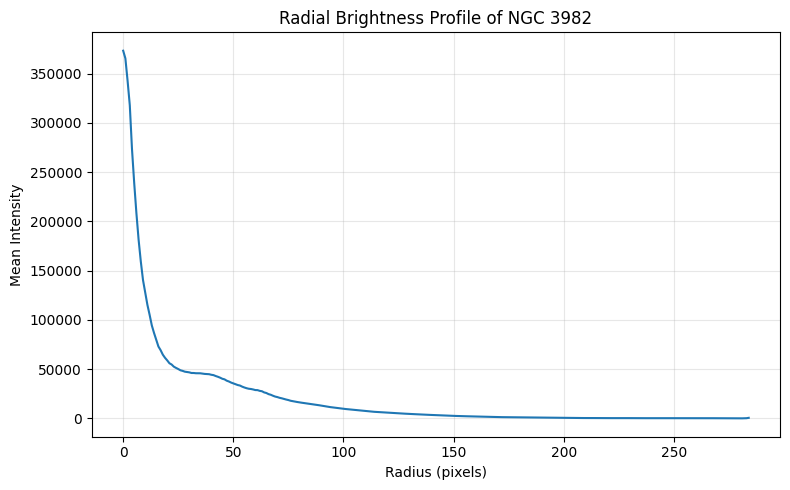

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(radii, mean_profile)
plt.xlabel("Radius (pixels)")
plt.ylabel("Mean Intensity")
plt.title("Radial Brightness Profile of NGC 3982")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

r20 = 30.22 px
r50 = 61.76 px
r80 = 103.84 px


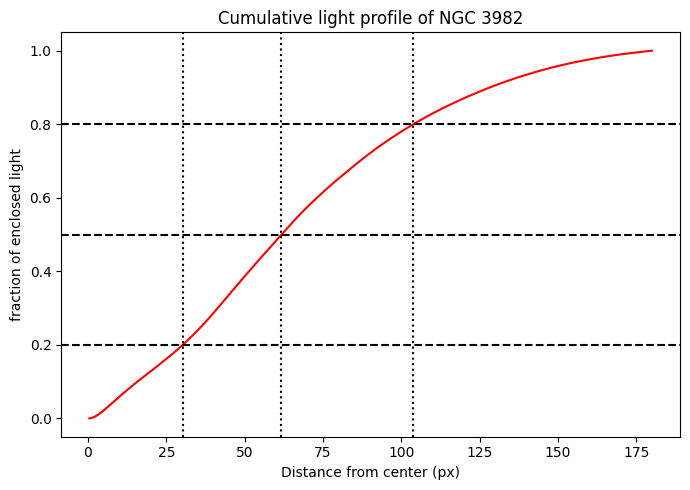

In [ ]:
xcen = 201.74
ycen = 198.62

y, x = np.indices(data.shape)
r = np.sqrt((x - xcen)**2 + (y - ycen)**2)

rmax = 180

r_flat = r.flatten()
flux_flat = data.flatten()

mask = r_flat <= rmax

r_use = r_flat[mask]
flux_use = flux_flat[mask]

order = np.argsort(r_use)

r_sorted = r_use[order]
flux_sorted = flux_use[order]

cumflux = np.cumsum(flux_sorted)
cumflux /= cumflux[-1]

r20 = r_sorted[np.searchsorted(cumflux, 0.20)]
r50 = r_sorted[np.searchsorted(cumflux, 0.50)]
r80 = r_sorted[np.searchsorted(cumflux, 0.80)]

print(f"r20 = {r20:.2f} px")
print(f"r50 = {r50:.2f} px")
print(f"r80 = {r80:.2f} px")

plt.figure(figsize=(7,5))
plt.plot(r_sorted, cumflux, color='red')

plt.axhline(0.2, ls='--', color='black')
plt.axhline(0.5, ls='--', color='black')
plt.axhline(0.8, ls='--', color='black')

plt.axvline(r20, ls=':', color='black')
plt.axvline(r50, ls=':', color='black')
plt.axvline(r80, ls=':', color='black')

plt.xlabel("Distance from center (px)")
plt.ylabel("fraction of enclosed light")
plt.title("Cumulative light profile of NGC 3982")
plt.tight_layout()
plt.show()

In [ ]:
edge_pixels = np.concatenate([
    data[:20, :].ravel(),
    data[-20:, :].ravel(),
    data[:, :20].ravel(),
    data[:, -20:].ravel()
])

background = np.median(edge_pixels)
background_std = np.std(edge_pixels)

print("Background median =", background)
print("Background std =", background_std)

Background median = 268.64005
Background std = 539.0355


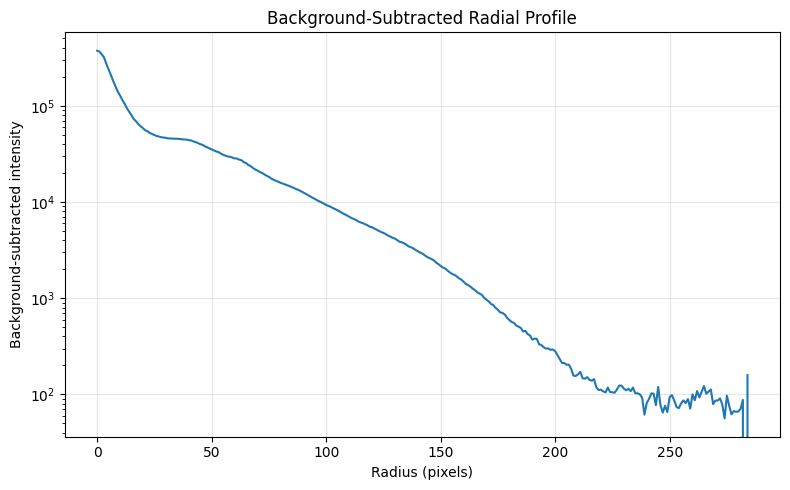

In [ ]:
background = 268.64005
data_sub = data - background

data_sub[data_sub < 0] = 0

xcen = 201.74
ycen = 198.62

y, x = np.indices(data.shape)
r = np.sqrt((x - xcen)**2 + (y - ycen)**2)
r_int = r.astype(int)

radii = np.arange(r_int.max() + 1)

mean_profile = np.array([
    data_sub[r_int == rad].mean()
    for rad in radii
])

plt.figure(figsize=(8,5))
plt.semilogy(radii, mean_profile)
plt.xlabel("Radius (pixels)")
plt.ylabel("Background-subtracted intensity")
plt.title("Background-Subtracted Radial Profile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from skimage.measure import find_contours, EllipseModel

Semi-major axis a = 104.99 px
Semi-minor axis b = 91.89 px
Axis ratio b/a = 0.875
Ellipticity = 0.125


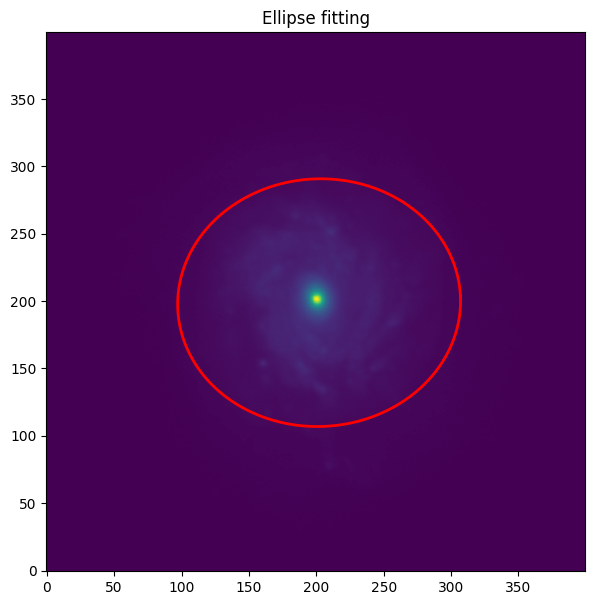

In [ ]:
background = 268.64005
data = data - background
data[data < 0] = 0

level = np.max(data) * 0.02

contours = find_contours(data, level)

contour = max(contours, key=len)

ellipse = EllipseModel()
ellipse.estimate(contour)

yc, xc, a, b, theta = ellipse.params

print(f"Semi-major axis a = {a:.2f} px")
print(f"Semi-minor axis b = {b:.2f} px")
print(f"Axis ratio b/a = {b/a:.3f}")

ellipticity = 1 - b/a
print(f"Ellipticity = {ellipticity:.3f}")

fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(data, origin='lower', cmap='viridis')

t = np.linspace(0, 2*np.pi, 500)

x = xc + a*np.cos(t)*np.cos(theta) - b*np.sin(t)*np.sin(theta)
y = yc + a*np.cos(t)*np.sin(theta) + b*np.sin(t)*np.cos(theta)

ax.plot(x, y, 'r', lw=2)

plt.title("Ellipse fitting")
plt.show()

In [ ]:
filename = "ngc3982_g.fits"

hdul = fits.open(filename)

hdul.info()

print("\nShape:", hdul[0].data.shape)
print("\nHeader keywords:")
print("NAXIS =", hdul[0].header.get("NAXIS"))
print("NAXIS1 =", hdul[0].header.get("NAXIS1"))
print("NAXIS2 =", hdul[0].header.get("NAXIS2"))

hdul.close()

Filename: ngc3982_g.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     227   (400, 400)   float32   

Shape: (400, 400)

Header keywords:
NAXIS = 2
NAXIS1 = 400
NAXIS2 = 400


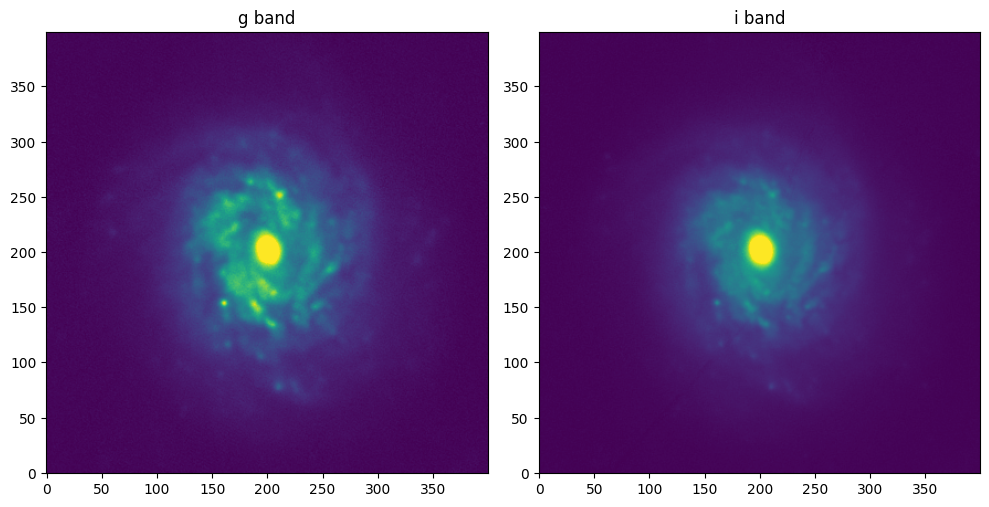

In [ ]:
g = fits.getdata("ngc3982_g.fits")
i = fits.getdata("ngc3982_i.fits")

interval = PercentileInterval(99.5)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

vmin, vmax = interval.get_limits(g)
ax[0].imshow(g, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
ax[0].set_title("g band")

vmin, vmax = interval.get_limits(i)
ax[1].imshow(i, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
ax[1].set_title("i band")

plt.tight_layout()
plt.show()

In [ ]:
edge_pixels = np.concatenate([
    g[:20, :].ravel(),
    g[-20:, :].ravel(),
    g[:, :20].ravel(),
    g[:, -20:].ravel()
])

background_g = np.median(edge_pixels)

g_sub = g - background_g
g_sub[g_sub < 0] = 0

xg, yg = centroid_com(g_sub)

print(f"g-band center: ({xg:.2f}, {yg:.2f})")

g-band center: (200.42, 197.61)


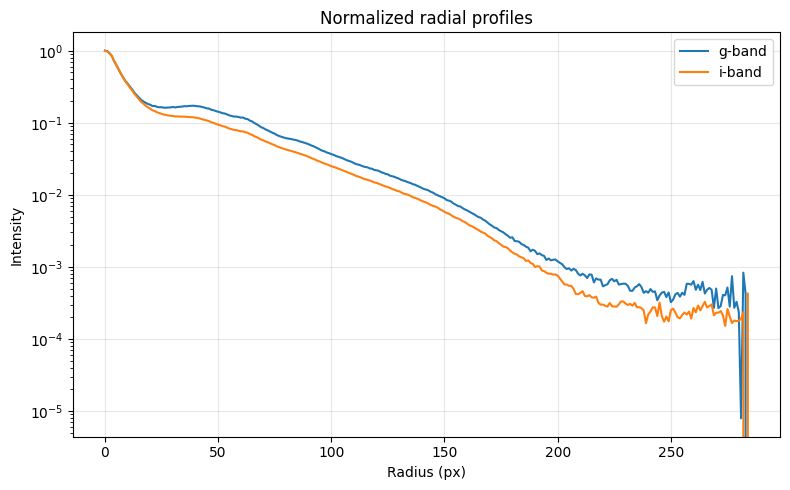

In [ ]:
bg_g = np.median(np.concatenate([
    g[:20,:].ravel(),
    g[-20:,:].ravel(),
    g[:,:20].ravel(),
    g[:,-20:].ravel()
]))

bg_i = np.median(np.concatenate([
    i[:20,:].ravel(),
    i[-20:,:].ravel(),
    i[:,:20].ravel(),
    i[:,-20:].ravel()
]))

g = g - bg_g
i = i - bg_i

g[g < 0] = 0
i[i < 0] = 0

xcen = 201.74
ycen = 198.62

y, x = np.indices(i.shape)
r = np.sqrt((x-xcen)**2 + (y-ycen)**2)
r_int = r.astype(int)

radii = np.arange(r_int.max()+1)

profile_g = np.array([
    g[r_int == rad].mean()
    for rad in radii
])

profile_i = np.array([
    i[r_int == rad].mean()
    for rad in radii
])

profile_g /= profile_g[0]
profile_i /= profile_i[0]

plt.figure(figsize=(8,5))
plt.semilogy(radii, profile_g, label='g-band')
plt.semilogy(radii, profile_i, label='i-band')

plt.xlabel("Radius (px)")
plt.ylabel("Intensity")
plt.title("Normalized radial profiles")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

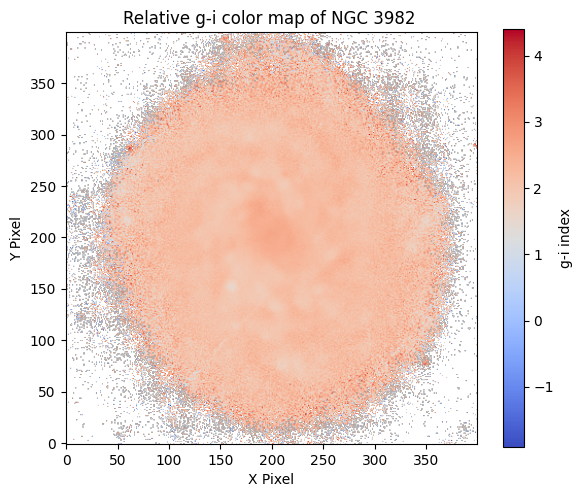

In [ ]:
bg_g = np.median(np.concatenate([
    g[:20,:].ravel(),
    g[-20:,:].ravel(),
    g[:,:20].ravel(),
    g[:,-20:].ravel()
]))

bg_i = np.median(np.concatenate([
    i[:20,:].ravel(),
    i[-20:,:].ravel(),
    i[:,:20].ravel(),
    i[:,-20:].ravel()
]))

g = g - bg_g
i = i - bg_i

g[g < 1] = 1
i[i < 1] = 1

color_map = -2.5 * np.log10(g / i)

mask = (g < 50) | (i < 50)
color_map[mask] = np.nan

plt.figure(figsize=(6,5))

im = plt.imshow(
    color_map,
    origin='lower',
    cmap='coolwarm'
)

plt.colorbar(im, label='g-i index')

plt.title("Relative g-i color map of NGC 3982 ")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.tight_layout()
plt.show()

In [ ]:
hdr_g = fits.getheader("ngc3982_g.fits")
hdr_i = fits.getheader("ngc3982_i.fits")

for key in hdr_g:
    if "ZP" in key.upper() or "MAG" in key.upper():
        print("g:", key, hdr_g[key])

for key in hdr_i:
    if "ZP" in key.upper() or "MAG" in key.upper():
        print("i:", key, hdr_i[key])

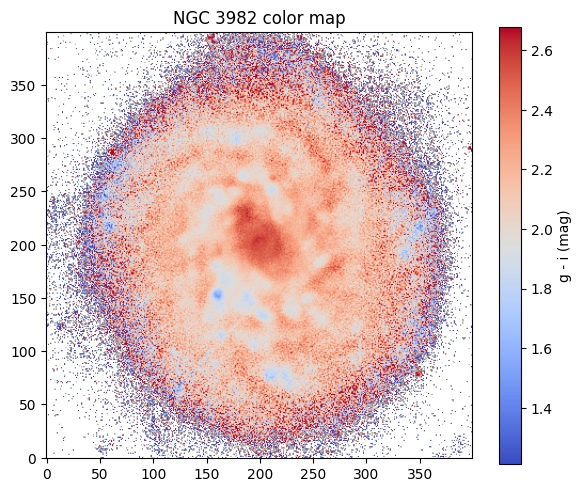

In [ ]:
vmin = np.nanpercentile(color_map, 5)
vmax = np.nanpercentile(color_map, 95)

plt.figure(figsize=(6,5))
plt.imshow(
    color_map,
    origin='lower',
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label='g - i (mag)')
plt.title('NGC 3982 color map')
plt.tight_layout()
plt.show()

In [ ]:
print(np.nanmin(color_map))
print(np.nanmax(color_map))
print(np.nanmedian(color_map))

-1.9038103
4.3975387
2.1205387


In [ ]:
xc = int(round(201.74))
yc = int(round(198.62))

print("Central g-i =", color_map[yc, xc])

Central g-i = 2.5400715


In [ ]:
rmax = 180

y, x = np.indices(color_map.shape)
r = np.sqrt((x-201.74)**2 + (y-198.62)**2)

mask = r < rmax

print("Median galaxy g-i =", np.nanmedian(color_map[mask]))
print("Mean galaxy g-i =", np.nanmean(color_map[mask]))

Median galaxy g-i = 2.130609
Mean galaxy g-i = 2.114256


In [ ]:
mask = (g < 200) | (i < 200)
color_map_clean = color_map.copy()
color_map_clean[mask] = np.nan

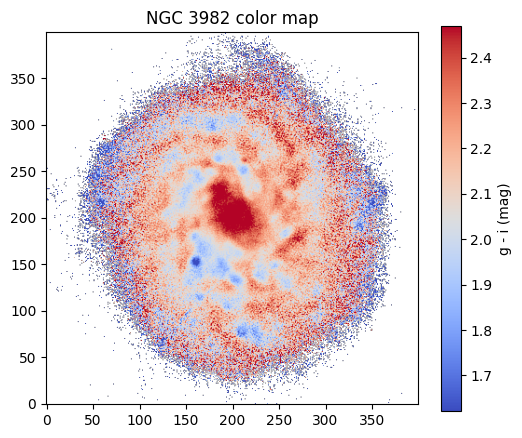

In [ ]:
vmin = np.nanpercentile(color_map_clean, 5)
vmax = np.nanpercentile(color_map_clean, 95)

plt.figure(figsize=(6,5))
plt.imshow(
    color_map_clean,
    origin='lower',
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label='g - i (mag)')
plt.title('NGC 3982 color map')
plt.show()